In [1]:
import sys
sys.path.append("/home/149/ab8992/tasman-tides/")
import xarray as xr
import ttidelib as tt
import scipy
import cmocean
import os
from pathlib import Path
cmap = cmocean.cm.dense_r
import matplotlib
import matplotlib.pyplot as plt
earth_cmap = matplotlib.colormaps["gist_earth"]
from datetime import timedelta
import warnings
warnings.simplefilter("ignore")
# import filtering
import numpy as np
import dask
dask.config.set({'logging.distributed': 'error'})
from dask.distributed import Client,default_client
import xrft


# client = tt.startdask(nthreads=1,n_workers = 40)

# client

[21]
loading u...	

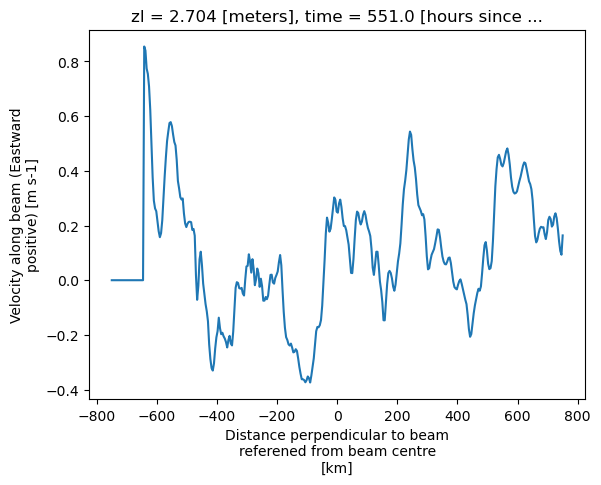

In [ ]:
def collect_data(exptname,rawdata = None,ppdata = None,lfiltered = None,chunks = None,timerange = (None,None)):
    """
    Collect all data required for analysis into a single xarray.Dataset
    expname : str
        Name of the experiment
    rawdata : list of str
        List of raw data variables to include
    ppdata : list of str
        List of postprocessed data variables to include. Note that thse aren't organised in to "outputs" given that they are often filtered temporally and so don't fit within the same output bins as model runs
    lfiltered : str. eg: "10000-highpass"
    outputs : str
        Glob string to match the output directories
    chunks : dict
        Chunks to use for dask. If "auto", use the default chunking for each variable. Surface variables are only given a time chunk
    timerange : Can choose the times instead of output. If None, use all times
    """
    #! As I've made mistakes in saving data, I've been correcting the mistakes retrospectively here
    res = exptname.split("-")[-1]

    if res == "20" and exptname != "blank-20":
        time_per_output = 15 * 24
    elif res == "10":
        time_per_output = 30 * 24
    elif res == "40" or exptname == "blank-20":
        time_per_output = 5 * 24
    elif res == "80":
        time_per_output = 1 * 24
    data = {}
    ## First handle the case of lfiltered data. Here, load the filtered
    ## data first, then extract the timerange information from it. Use
    ## this to load the raw data via a recursive collect_data call
    if type(lfiltered) != type(None):
        prefix = ""
        if "-" in lfiltered:
            prefix = lfiltered.split("-")[1]
            t0 = lfiltered.split("-")[0]
        if prefix == "highpass": #! This is a really lazy fix, but I mixed up lowpass and highpass in the filter script. 
            prefix = "lowpass"   #! This undoes the mistake without having to go back and rename a bunch of stuff
        elif prefix == "lowpass":#! while keeping analysis scripts consistent
            prefix = "highpass"
        
        else:
            t0 = lfiltered
        ldata = xr.open_mfdataset(
            str(Path("/g/data/nm03/ab8992/postprocessed") / exptname / "lfiltered" /  f"bp-t0-{t0}/{prefix}*.nc"),
            decode_times = False,lock = False,
            decode_cf=False)
        timerange = (ldata.time.values[0],ldata.time.values[-1])
        print(f"Timerange as inferred from lfiltered data: {timerange}")
        # iterate over every data variable in the lfiltered dataset
        for var in ldata:
            if var == "cst":
                data[var] = ldata[var]
            data[f"{var}_lf"] = ldata[var]       

    if None in timerange:
        rawdata_paths = list(
            Path(f"/g/data/nm03/ab8992/outputs/{exptname}/").glob('output*')
            )
    else:
        outputs = np.arange(
            np.floor(timerange[0] /time_per_output),
            np.ceil(timerange[1] / time_per_output)
        ).astype(int)
        # change these outputs to strings with 3 digits
        if "80" in exptname:
            outputs -= (496 - 91) #! Here need to account for erroneous offset. 80th wasn't reset to start from zero, so clock starts from 496 days. First output is at output 91 after spinup
            print(f"80th run: adjusting outputs to {outputs}")
        if "dissipation" in exptname:
            times_per_output = 24*15

            offset_start = timerange[0] - 481
            offset_end = timerange[1] - 481
            first_output = np.floor(offset_start / times_per_output) + 21
            last_output = np.ceil(offset_end / times_per_output) + 21
            outputs = np.arange(int(first_output),int(last_output))
            print(outputs)
        rawdata_paths = [f"/g/data/nm03/ab8992/outputs/{exptname}/output{i:03d}" for i in outputs]

    ppdata_path = Path("/g/data/nm03/ab8992/postprocessed/") / exptname


    if type(rawdata) != type(None):
        
        for var in rawdata:
            print(f"loading {var}...",end = "\t" )

            # Collect list of files to load
            all_files = []
            # Loop over each path in the paths list
            for path in rawdata_paths:
                # Convert the path to a Path object
                path = Path(path) / var
                # Use glob to find all files that match the pattern
                files = list(path.glob('*.nc'))
                # Add the files to the all_files list
                all_files.extend(files)

            # Now pass all the files instead of a wildcard string
            data[var] = xr.open_mfdataset(all_files, decode_times=False, parallel = True,decode_cf=False,lock = False).sel(time = slice(timerange[0],timerange[1]))[var]
            return data[var]

        #! I messed up the rotation! This fixes the velocity rotation on data load.
        if "u" in rawdata and "v" in rawdata:
            u_rotated_once,v_rotated_once = tt.anticlockwise_rotation(data["u"],data["v"])
            u_rotated_once, v_rotated_once = tt.anticlockwise_rotation(u_rotated_once,v_rotated_once)

            data["u"] = u_rotated_once.rename("u")
            data["v"] = v_rotated_once.rename("v")

    if type(ppdata) != type(None):
        for var in ppdata:
            print(f"loading {var} topdown...",end = "\t" )
            data[var + "_topdown"] = xr.open_mfdataset(
                str(ppdata_path / var / "topdown" / "*.nc"),chunks = chunks,decode_times = False,lock = False,decode_cf = False).sel(time = slice(timerange[0],timerange[1])
            )[var].rename(f"{var}_topdown")
            print("done. loading transect...",end = "\t")
            data[var + "_transect"] = xr.open_mfdataset(
                str(ppdata_path / var / "transect" / "*.nc"),chunks = chunks,decode_times = False,lock = False,decode_cf = False).sel(time = slice(timerange[0],timerange[1])
            )[var].rename(f"{var}_transect")
            print("done.")


    data["bathy"] = -1 * xr.open_mfdataset(str(Path("/g/data/nm03/ab8992/outputs/") / exptname / "bathy_transect.nc")).rename({"depth":"bathy"})


    data = xr.merge([data[i] for i in data])

    ## Weird thing with smooth and ideal that ntiles remains a dim
    if "ntiles" in data.dims:
        data = data.isel(ntiles = 0)
    return data
expt = "4xdissipation-full-20"

u = collect_data(expt,rawdata = "u",timerange = [550,650]).isel(zl = 0,xb = 100).load()

u.isel(time = 1).plot()

In [17]:
bathy_raw = xr.open_dataset("/g/data/nm03/ab8992/ttide-inputs/full-20/topog_raw.nc")

bathy_beamgrid = (-1 * tt.beamgrid(bathy_raw,xname = "lon",yname = "lat")).rename({"elevation":"depth"})

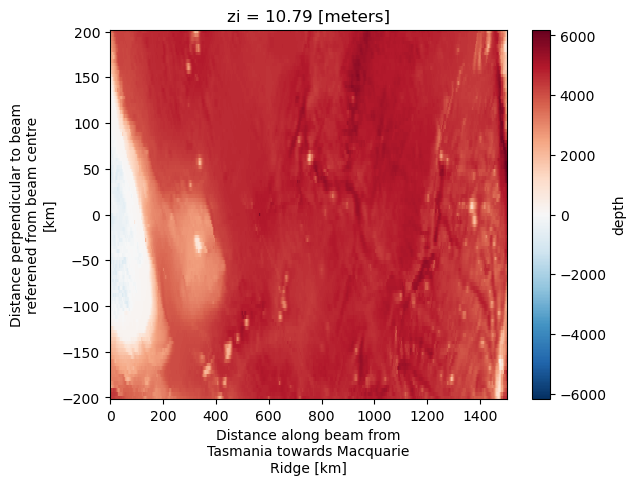

In [16]:
regular_beamgrid = xr.open_dataset("/g/data/nm03/ab8992/outputs/full-20/bathy_transect.nc")
regular_beamgrid.depth.plot()

In [21]:
bathy_beamgrid.to_netcdf("/g/data/nm03/ab8992/outputs/1xdissipation-full-20/bathy_transect.nc")

loading u...	done.


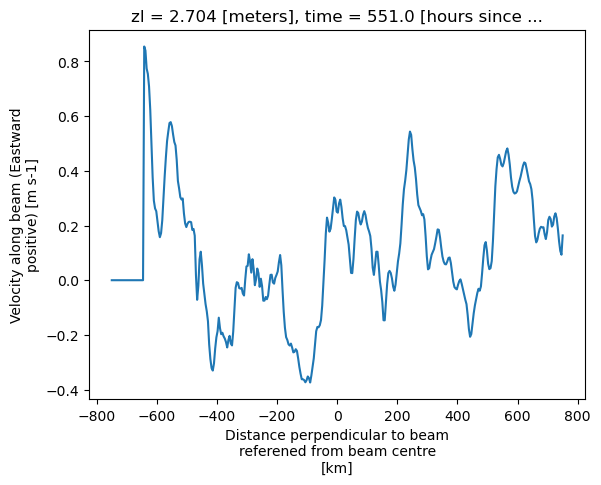

In [23]:
expt = "4xdissipation-full-20"

u = tt.collect_data(expt,rawdata = "u",timerange = [550,650]).isel(zl = 0,xb = 100).load()
u.u.isel(time = 1).plot()

In [ ]:
# output 21 first time = 481. After that, increment upwards by 24 * 15
times_per_output = 24*15
timerange = (1000,1100)

offset_start = timerange[0] - 481
offset_end = timerange[1] - 481
first_output = np.floor(offset_start / times_per_output)
last_output = np.ceil(offset_end / times_per_output)
outputs = np.arange(int(first_output),int(last_output))
print(21 + first_output,21 + last_output)

22.0 23.0


loading u...	done.


ValueError: Dimensions {'xb'} do not exist. Expected one or more of ('time', 'yb')

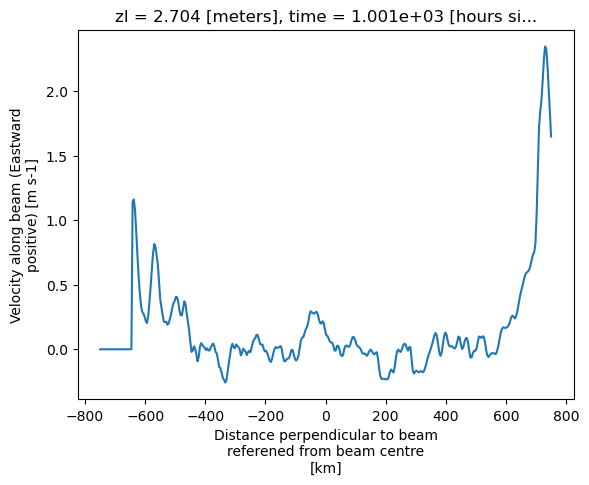

In [22]:
# IN this cell, we see that the manual loading of the data works fine, but collect data has nans in the middle. Need to figure
# out why collect data now messed up ??

# Issue was dodgy data maybe? Works for outputs 20-25, breaks at 28.

expt = "4xdissipation-full-20"
u = tt.collect_data(expt,rawdata = "u",timerange = [1000,1100]).isel(zl = 0,xb = 100).load()
u_manual = xr.open_mfdataset("/g/data/nm03/ab8992/outputs/4xdissipation-full-20/output022/u/u_*",decode_times = False).isel(zl = 0).load()
u_manual.u.isel(xb = 100).sel(time = 1001).plot()
u.u.isel(xb = 100).sel(time = 1001).plot()

In [53]:
u_manual = xr.open_mfdataset("/g/data/nm03/ab8992/outputs/4xdissipation-full-20/output028/u/u_*",decode_times = False).isel(zl = 0).load()
u_manual.u.isel(xb = 100).sel(time = 1001).plot()

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

Check with same load settings 

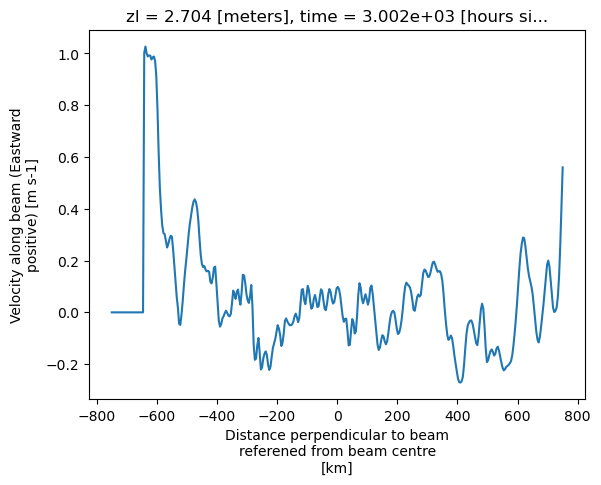

In [55]:
u_manual_adjusted = xr.open_mfdataset("/g/data/nm03/ab8992/outputs/4xdissipation-full-20/output028/u/u_*",decode_times=False, parallel = True,decode_cf=False,lock = False).isel(zl = 0).load()
u_manual_adjusted.u.isel(xb = 100).isel(time = 1).plot()
# u.u.isel(xb = 100).sel(time = 1001).plot()            


In [17]:
u_sliced = xr.open_mfdataset("/g/data/nm03/ab8992/outputs/4xdissipation-full-20/output022/u/u_y3*").isel(zl = 0).load()

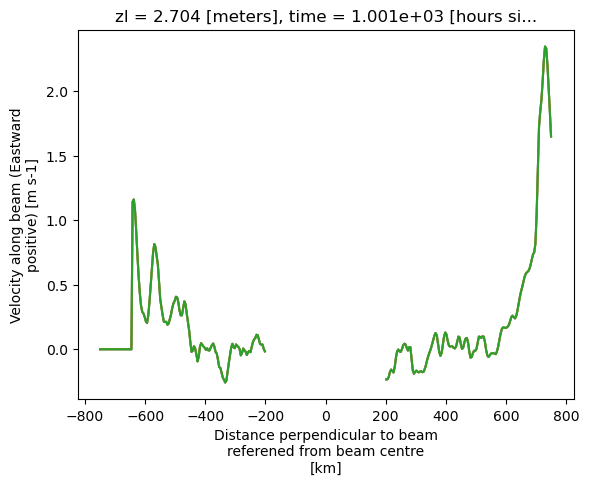

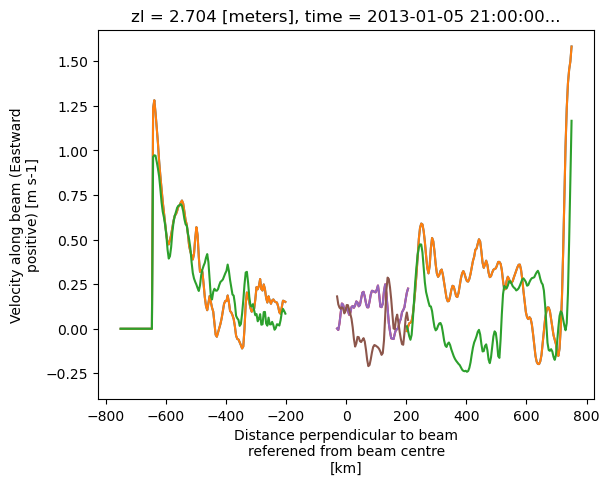

In [18]:
u.u.isel(time = 80,xb = 100).load().plot()
u.u.isel(time = 80,xb = 100).load().plot()
u.u.isel(time = 20,xb = 100).load().plot()
u_sliced.u.isel(time = 80,xb = 100).load().plot()
u_sliced.u.isel(time = 80,xb = 100).load().plot()
u_sliced.u.isel(time = 20,xb = 100).load().plot()


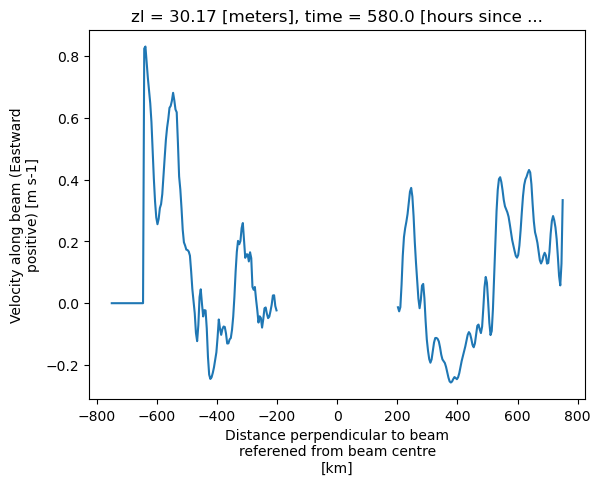

In [12]:
u.u.isel(time = 80,zl = 5,xb = 100).load().plot()

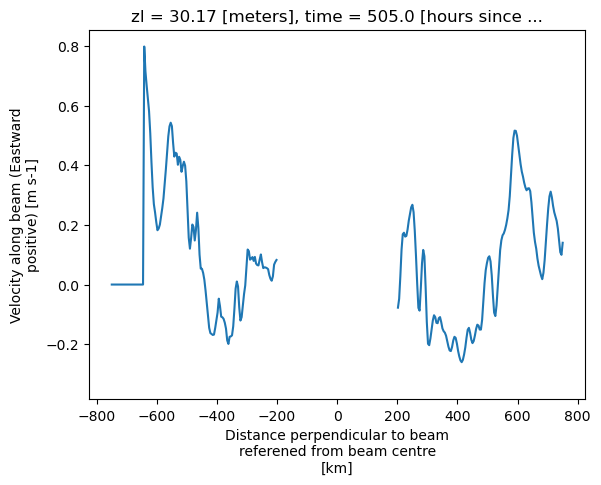

In [10]:
u.u.isel(time = 5,zl = 5,xb = 100).load().plot()

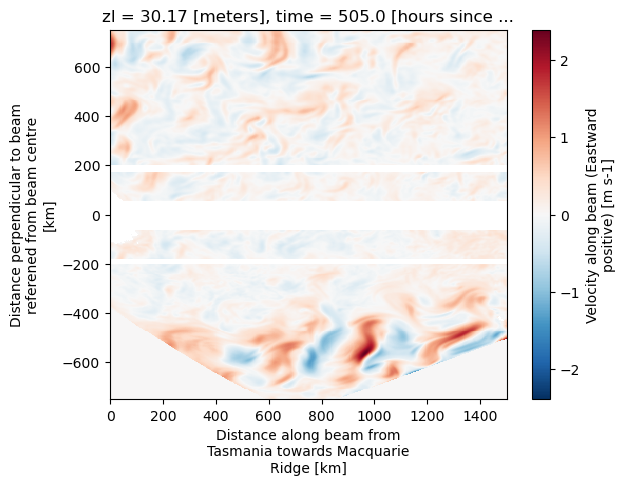

In [5]:
u.u.isel(time = 5,zl = 5).plot()

In [2]:
# sys.path.append("/home/149/ab8992/libraries/lagrangian-filtering")
import filtering


sh: None: command not found
INFO: Compiled ParcelsRandom ==> /jobfs/164778027.gadi-pbs/parcels-16078/libparcels_random_2ed0b39b-aa3f-494e-85c7-6b921125f5a5.so


In [16]:
bathy

<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 795, lon: 760)
Coordinates:
  * lat        (lat) float64 6kB -55.98 -55.94 -55.91 ... -26.09 -26.06 -26.02
  * lon        (lon) float64 6kB 142.0 142.1 142.1 142.2 ... 179.9 179.9 180.0
Data variables:
    elevation  (lat, lon) float64 5MB ...
Attributes:
    regrid_method:  bilinear

In [17]:
# Test new beamgrid
# u = xr.open_dataset("/scratch/nm03/ab8992/mom6/archive/4xdissipation-full-20-53d8fc32/output010/20121210.u.nc")
bathy = xr.open_dataset("/g/data/nm03/ab8992/ttide-inputs/full-20/topog_raw.nc")
# u_bg = tt.beamgrid(u,xname = "xq")
bathy_bg = tt.beamgrid(bathy.elevation,xname = "lon",yname = "lat")

In [25]:
bathy_bg

<xarray.DataArray 'elevation' (yb: 376, xb: 376)> Size: 1MB
array([[    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        , ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [-4912.0960076 , -4884.75121759, -4856.99615689, ...,
         -821.64707181,  -824.24116701,  -821.34491811],
       [-5002.04287936, -4937.41700018, -4829.48368939, ...,
         -813.65144672,  -814.31356948,  -802.63711187],
       [-5008.25002261, -4959.41430736, -4893.06293554, ...,
         -795.59737369,  -801.3495227 ,  -799.23149384]], shape=(376, 376))
Coordinates:
  * yb       (yb) float64 3kB -750.0 -746.0 -742.0 -738.0 ... 742.0 746.0 750.0
  * xb       (xb) float64 3kB -0.0 4.0 8.0 12.0 ... 1.492e+03 1.496e+03 1.5e+03
    lon      (yb, xb) float64 1MB 134.8 134.8 134.9 134.9 ... 169.4 169.4 169.5
    lat      (yb, xb) float64 1MB -51.3 -51.32 -51.34 ... -40.1 -40.12 -40.13
Attributes:
    Description:  Beamwidth 1500km, Beamlength 1500km, Resolution 4.0km, angl...

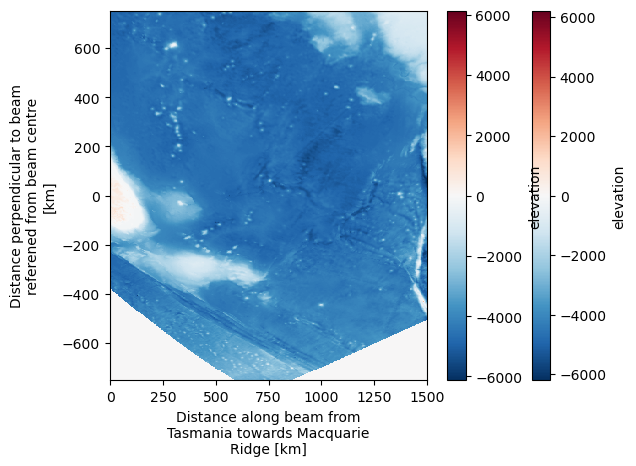

In [24]:
bathy.elevation.plot()
bathy_bg.plot()

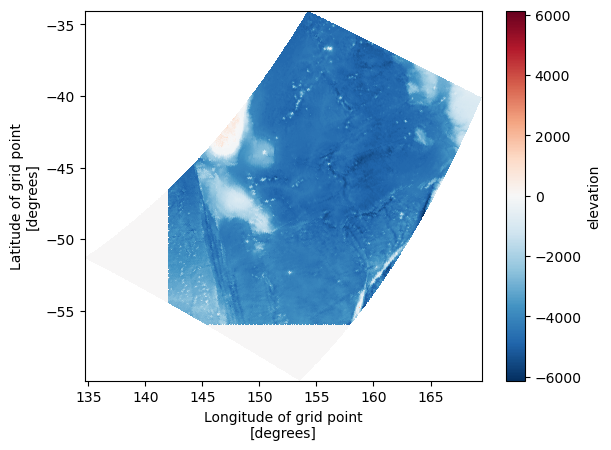

In [26]:
bathy_bg.plot(x = "lon",y = "lat")

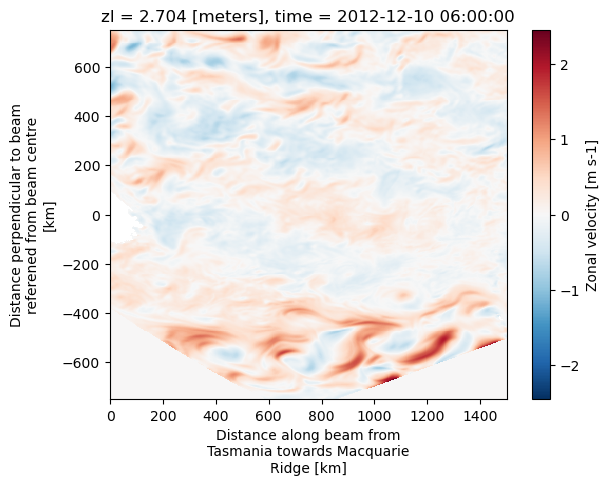

In [9]:
u_bg.u.isel(zl = 0,time = 5).plot()

In [108]:
tmpstorage = os.getenv('PBS_JOBFS')
tmpstorage = "/scratch/nm03/ab8992/test"
outputdir = "/scratch/nm03/ab8992/test/outputs"
expts = ["full-10","beamless-10","smooth-10","beamless-20","smooth-20","full-20","full-40","beamless-40","smooth-40"]

expt = "full-20"

for expt in expts:
    outputdir = "/scratch/nm03/ab8992/forcallum/outputs/"+expt

    # def save_temporary(expt,t0,outputdir):
    """
    Open all the datasets that we need for this experiment. Save some of the simple stuff, and save the modal decompossitions to temporary storage chunked by mode for further processing.
    """
    with (
            xr.open_mfdataset(f"/g/data/nm03/ab8992/postprocessed/figdata/snapshots/{expt}/u*.nc",decode_times = False) as uamp,
            xr.open_mfdataset(f"/g/data/nm03/ab8992/postprocessed/figdata/snapshots/{expt}/v*.nc",decode_times = False) as vamp
    ):
        if "80" in expt: #! vmodes have failed for some times. For now, fix vmodes to match for each run
            vmodes= xr.open_dataset(f"/g/data/nm03/ab8992/postprocessed/{expt}/vertical_eigenfunctions/vmode-t0-{12258}.nc",decode_times = False,chunks = {"mode":1}).isel(zl = slice(0,96))
            vmodes = vmodes.interp_like(uamp.u.isel(time = 0)).persist() ## Now need to chunk this on disk like the Filtered data
            print("vmodes interpolated")
            ## Fix messed up times:
        elif "40" in expt: #! vmodes have failed for some times. For now, fix vmodes to match for each run
            vmodes = xr.open_dataset(f"/g/data/nm03/ab8992/postprocessed/{expt}/vertical_eigenfunctions/vmode-t0-{4216}.nc",decode_times = False,chunks = {"mode":1}).isel(zl = slice(0,96))
        else:
            vmodes = xr.open_dataset(f"/g/data/nm03/ab8992/postprocessed/{expt}/vertical_eigenfunctions/vmode-t0-{22000}.nc",decode_times = False,chunks = {"mode":1}).isel(zl = slice(0,96))

            
        # os.remove(f"{tmpstorage}/*.nc")
        # vmodes = vmodes.assign_coords({"zl":filtered.zl})
        ymin = vmodes.yb[0].values - 0.0001 ## This ensures random numerical changes of 1e-16 to axis values don't cause issues... 
        ymax = vmodes.yb[-1].values + 0.0001
        topo = xr.open_dataset(f"/g/data/nm03/ab8992/outputs/{expt}/bathy_transect.nc").depth

        zgrid = vmodes.zl.expand_dims({"xb":vmodes.xb,"yb":vmodes.yb}).transpose("yb","xb","zl")
        zgrid_offset = zgrid.roll(zl = -1)
        zgrid_offset[:,:,-1] = 10000
        zgrid_offset[:,:,0] = 0

        vmode_bottom = vmodes.U.where((zgrid < topo) * (zgrid_offset > topo ),0).sum("zl")

        ubot = vmode_bottom * np.abs(uamp).max("time")
        vbot = vmode_bottom * np.abs(vamp).max("time")
        N = xr.open_dataset(outputdir +  "/N.nc")
        f = 2 * 7.2921e-5 * np.sin(np.deg2rad(N.lat))

        f.to_netcdf(f"{outputdir}/f.nc")
        ubot.to_netcdf(f"{outputdir}/uba.nc")
        vbot.to_netcdf(f"{outputdir}/vba.nc")


In [94]:
N.lat.values

array([[-43.51988247, -43.53760212, -43.55532697, ..., -50.55572877,
        -50.57595459, -50.59618909],
       [-43.47356336, -43.49126941, -43.50898066, ..., -50.50287146,
        -50.52307462, -50.54328643],
       [-43.42727972, -43.44497222, -43.4626699 , ..., -50.45007325,
        -50.47025384, -50.49044304],
       ...,
       [-40.79994426, -40.81691781, -40.8338957 , ..., -47.48127603,
        -47.50028904, -47.51930894],
       [-40.75557242, -40.77253462, -40.78950116, ..., -47.4315822 ,
        -47.45057723, -47.46957914],
       [-40.71123017, -40.72818107, -40.74513629, ..., -47.38193524,
        -47.40091237, -47.41989635]])

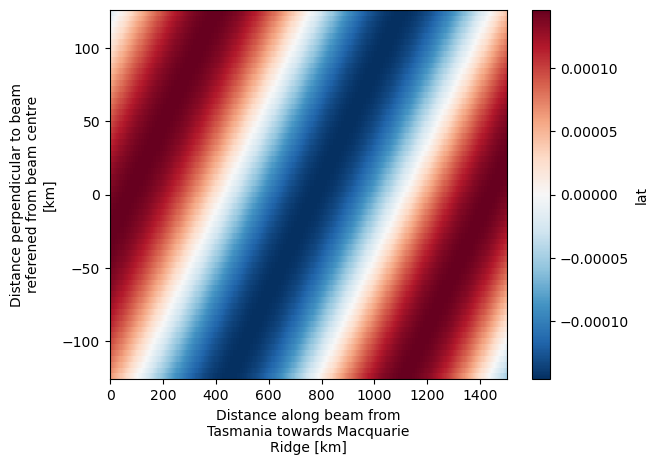

In [91]:
f.plot()

In [60]:
print(zgrid.zl)
print(zgrid.roll(zl = -1,roll_coords=True).zl)

<xarray.DataArray 'zl' (zl: 96)>
array([2.703753e+00, 8.125880e+00, 1.357918e+01, 1.906775e+01, 2.459623e+01,
       3.016989e+01, 3.579464e+01, 4.147720e+01, 4.722515e+01, 5.304703e+01,
       5.895252e+01, 6.495250e+01, 7.105930e+01, 7.728676e+01, 8.365052e+01,
       9.016818e+01, 9.685954e+01, 1.037469e+02, 1.108551e+02, 1.182124e+02,
       1.258502e+02, 1.338036e+02, 1.421120e+02, 1.508192e+02, 1.599741e+02,
       1.696308e+02, 1.798495e+02, 1.906965e+02, 2.022449e+02, 2.145749e+02,
       2.277741e+02, 2.419380e+02, 2.571697e+02, 2.735803e+02, 2.912884e+02,
       3.104201e+02, 3.311080e+02, 3.534903e+02, 3.777098e+02, 4.039118e+02,
       4.322427e+02, 4.628474e+02, 4.958665e+02, 5.314341e+02, 5.696743e+02,
       6.106986e+02, 6.546025e+02, 7.014638e+02, 7.513394e+02, 8.042643e+02,
       8.602503e+02, 9.192855e+02, 9.813352e+02, 1.046342e+03, 1.114229e+03,
       1.184899e+03, 1.258243e+03, 1.334134e+03, 1.412441e+03, 1.493021e+03,
       1.575730e+03, 1.660421e+03, 1.746950

In [66]:
zgrid[0,0,:]

<xarray.DataArray 'zl' (zl: 96)>
array([2.70375301e+00, 8.12588010e+00, 1.35791760e+01, 1.90677463e+01,
       2.45962339e+01, 3.01698881e+01, 3.57946428e+01, 4.14772039e+01,
       4.72251476e+01, 5.30470310e+01, 5.89525152e+01, 6.49525037e+01,
       7.10592963e+01, 7.72867610e+01, 8.36505247e+01, 9.01681844e+01,
       9.68595415e+01, 1.03746858e+02, 1.10855141e+02, 1.18212446e+02,
       1.25850216e+02, 1.33803637e+02, 1.42112026e+02, 1.50819239e+02,
       1.59974094e+02, 1.69630816e+02, 1.79849482e+02, 1.90696464e+02,
       2.02244855e+02, 2.14574860e+02, 2.27774128e+02, 2.41938013e+02,
       2.57169714e+02, 2.73580277e+02, 2.91288419e+02, 3.10420127e+02,
       3.31108007e+02, 3.53490333e+02, 3.77709781e+02, 4.03911816e+02,
       4.32242730e+02, 4.62847362e+02, 4.95866507e+02, 5.31434115e+02,
       5.69674335e+02, 6.10698551e+02, 6.54602521e+02, 7.01463765e+02,
       7.51339365e+02, 8.04264271e+02, 8.60250256e+02, 9.19285547e+02,
       9.81335194e+02, 1.04634212e+03, 1.11422879e+03, 1.18489946e+03,
       1.25824274e+03, 1.33413449e+03, 1.41244075e+03, 1.49302073e+03,
       1.57572958e+03, 1.66042103e+03, 1.74694959e+03, 1.83517260e+03,
       1.92495179e+03, 2.01615453e+03, 2.10865486e+03, 2.20233405e+03,
       2.29708106e+03, 2.39279268e+03, 2.48937357e+03, 2.58673607e+03,
       2.68479998e+03, 2.78349220e+03, 2.88274637e+03, 2.98250241e+03,
       3.08270609e+03, 3.18330859e+03, 3.28426606e+03, 3.38553918e+03,
       3.48709276e+03, 3.58889537e+03, 3.69091895e+03, 3.79313848e+03,
       3.89553171e+03, 3.99807884e+03, 4.10076227e+03, 4.20356637e+03,
       4.30647727e+03, 4.40948267e+03, 4.51257168e+03, 4.61573463e+03,
       4.71896296e+03, 4.82224910e+03, 4.92558633e+03, 5.02896874e+03])
Coordinates:
    xb       float64 -0.0
    yb       float64 -120.0
  * zl       (zl) float64 2.704 8.126 13.58 ... 4.822e+03 4.926e+03 5.029e+03
Attributes:
    units:      meters
    long_name:  Depth at cell center
    axis:       Z
    positive:   down
    edges:      z_i

In [65]:
zgrid_offset[0,0,:]

<xarray.DataArray 'zl' (zl: 96)>
array([5.02896874e+03, 2.70375301e+00, 8.12588010e+00, 1.35791760e+01,
       1.90677463e+01, 2.45962339e+01, 3.01698881e+01, 3.57946428e+01,
       4.14772039e+01, 4.72251476e+01, 5.30470310e+01, 5.89525152e+01,
       6.49525037e+01, 7.10592963e+01, 7.72867610e+01, 8.36505247e+01,
       9.01681844e+01, 9.68595415e+01, 1.03746858e+02, 1.10855141e+02,
       1.18212446e+02, 1.25850216e+02, 1.33803637e+02, 1.42112026e+02,
       1.50819239e+02, 1.59974094e+02, 1.69630816e+02, 1.79849482e+02,
       1.90696464e+02, 2.02244855e+02, 2.14574860e+02, 2.27774128e+02,
       2.41938013e+02, 2.57169714e+02, 2.73580277e+02, 2.91288419e+02,
       3.10420127e+02, 3.31108007e+02, 3.53490333e+02, 3.77709781e+02,
       4.03911816e+02, 4.32242730e+02, 4.62847362e+02, 4.95866507e+02,
       5.31434115e+02, 5.69674335e+02, 6.10698551e+02, 6.54602521e+02,
       7.01463765e+02, 7.51339365e+02, 8.04264271e+02, 8.60250256e+02,
       9.19285547e+02, 9.81335194e+02, 1.04634212e+03, 1.11422879e+03,
       1.18489946e+03, 1.25824274e+03, 1.33413449e+03, 1.41244075e+03,
       1.49302073e+03, 1.57572958e+03, 1.66042103e+03, 1.74694959e+03,
       1.83517260e+03, 1.92495179e+03, 2.01615453e+03, 2.10865486e+03,
       2.20233405e+03, 2.29708106e+03, 2.39279268e+03, 2.48937357e+03,
       2.58673607e+03, 2.68479998e+03, 2.78349220e+03, 2.88274637e+03,
       2.98250241e+03, 3.08270609e+03, 3.18330859e+03, 3.28426606e+03,
       3.38553918e+03, 3.48709276e+03, 3.58889537e+03, 3.69091895e+03,
       3.79313848e+03, 3.89553171e+03, 3.99807884e+03, 4.10076227e+03,
       4.20356637e+03, 4.30647727e+03, 4.40948267e+03, 4.51257168e+03,
       4.61573463e+03, 4.71896296e+03, 4.82224910e+03, 1.00000000e+04])
Coordinates:
    xb       float64 -0.0
    yb       float64 -120.0
  * zl       (zl) float64 2.704 8.126 13.58 ... 4.822e+03 4.926e+03 5.029e+03
Attributes:
    units:      meters
    long_name:  Depth at cell center
    axis:       Z
    positive:   down
    edges:      z_i

In [83]:
print((zgrid < topo.depth).isel(yb = 50,xb = 50).values)
print((zgrid_offset > topo.depth).isel(yb = 50,xb = 50).values)
print(((zgrid < topo.depth) * (zgrid_offset > topo.depth)).isel(yb = 50,xb = 50).values)


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False False False False False False False]
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False F

In [ ]:
zgrid = vmodes.zl.expand_dims({"xb":vmodes.xb,"yb":vmodes.yb}).transpose("yb","xb","zl")
zgrid_offset = zgrid.roll(zl = -1)
zgrid_offset[:,:,-1] = 10000
zgrid_offset[:,:,0] = 0

vmode_bottom = vmodes.U.where((zgrid < topo.depth) * (zgrid_offset > topo.depth ),0).sum("zl")

ubot = vmode_bottom * uamp.u
vbot = vmode_bottom * uamp.v

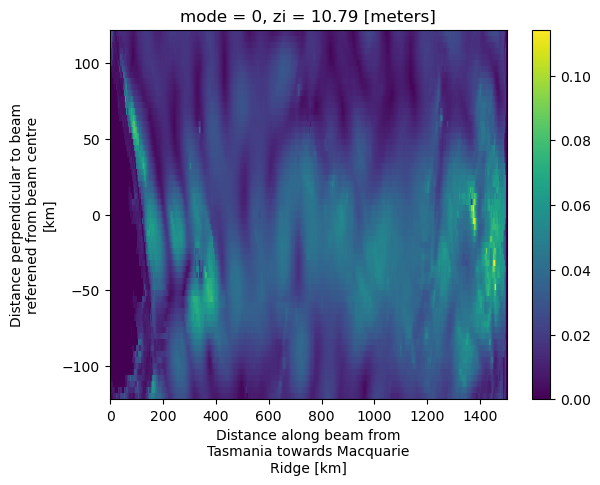

In [87]:
bottom_amplitude.max("time").plot()

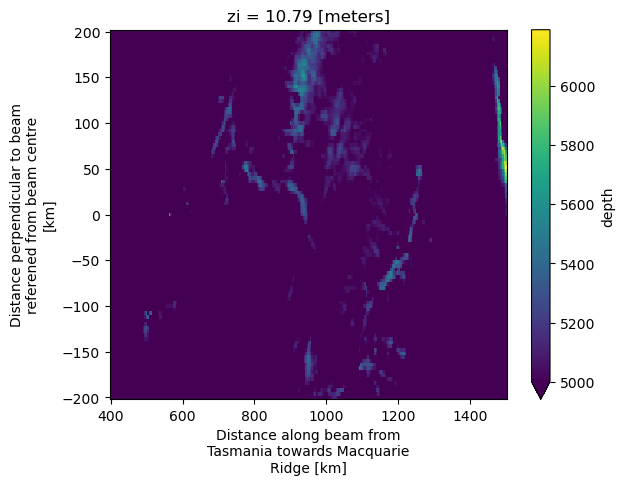

In [79]:
topo.depth.sel(xb = slice(400,None)).plot(vmin = 5000)

In [15]:
import shutil
expts = ["full-10","beamless-10","smooth-10","beamless-20","smooth-20","full-20","full-40","beamless-40","smooth-40"]
expts = ["full-40","beamless-40","smooth-40"]
# expts = ["full-40","beamless-40","smooth-40"]
# expts = ["full-10"]
t0_20th = 22000
t0_40th = 4216
t0_80th = 12023
for expt in expts:
    outputdir = "/scratch/nm03/ab8992/forcallum/outputs/"+expt
    tmpstorage = "/scratch/nm03/ab8992/forcallum/tmpstorage/"+expt
    t0 = t0_20th
    if "40" in expt:
        t0 = t0_40th
    if not os.path.exists(outputdir):
        os.makedirs(outputdir)
    if not os.path.exists(tmpstorage):
        os.makedirs(tmpstorage)
    print(expt)

    save_temporary(expt,t0,outputdir)
    # save_modal(outputdir)
    print("Done with ",expt)
    # clear_output()

full-40


2025-10-08 12:53:23,278 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.74 GiB -- Worker memory limit: 10.40 GiB
2025-10-08 12:53:23,666 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 8.53 GiB -- Worker memory limit: 10.40 GiB
2025-10-08 12:53:26,713 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.66 GiB -- Worker memory limit: 10.40 GiB
2025-10-08 12:53:27,141 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process m

KilledWorker: Attempted to run task ('mul-store-map-6d94723bfd0cfc73518b3887c8ae0856', 0, 0, 0, 0, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:43717. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [11]:
uamp = xr.open_dataset("/g/data/nm03/ab8992/postprocessed/figdata/snapshots/full-20/u_1.nc")
vmode = xr.open_dataset("/g/data/nm03/ab8992/postprocessed/full-20/vertical_eigenfunctions/vmode-t0-22000.nc")


In [21]:
vmode.U.yb.values

array([-120., -116., -112., -108., -104., -100.,  -96.,  -92.,  -88.,
        -84.,  -80.,  -76.,  -72.,  -68.,  -64.,  -60.,  -56.,  -52.,
        -48.,  -44.,  -40.,  -36.,  -32.,  -28.,  -24.,  -20.,  -16.,
        -12.,   -8.,   -4.,    0.,    4.,    8.,   12.,   16.,   20.,
         24.,   28.,   32.,   36.,   40.,   44.,   48.,   52.,   56.,
         60.,   64.,   68.,   72.,   76.,   80.,   84.,   88.,   92.,
         96.,  100.,  104.,  108.,  112.,  116.,  120.])

In [20]:
vmode.U.isel(mode = [0]).yb.values

array([-120., -116., -112., -108., -104., -100.,  -96.,  -92.,  -88.,
        -84.,  -80.,  -76.,  -72.,  -68.,  -64.,  -60.,  -56.,  -52.,
        -48.,  -44.,  -40.,  -36.,  -32.,  -28.,  -24.,  -20.,  -16.,
        -12.,   -8.,   -4.,    0.,    4.,    8.,   12.,   16.,   20.,
         24.,   28.,   32.,   36.,   40.,   44.,   48.,   52.,   56.,
         60.,   64.,   68.,   72.,   76.,   80.,   84.,   88.,   92.,
         96.,  100.,  104.,  108.,  112.,  116.,  120.])

In [24]:
a = uamp.u.isel(mode = [0])
b = vmode.U.isel(mode = [0])

In [ ]:
b.

<xarray.DataArray 'U' (mode: 1, zl: 100, yb: 61, xb: 376)>
[2293600 values with dtype=float64]
Coordinates:
  * mode     (mode) int64 0
  * zl       (zl) float64 2.704 8.126 13.58 ... 5.236e+03 5.339e+03 5.443e+03
  * xb       (xb) float64 -0.0 4.0 8.0 12.0 ... 1.492e+03 1.496e+03 1.5e+03
  * yb       (yb) float64 -120.0 -116.0 -112.0 -108.0 ... 112.0 116.0 120.0

In [29]:
a

<xarray.DataArray 'u' (mode: 1, yb: 61, xb: 376, time: 233)>
[5344088 values with dtype=float64]
Coordinates:
  * mode     (mode) int64 1
  * xb       (xb) float64 -0.0 4.0 8.0 12.0 ... 1.492e+03 1.496e+03 1.5e+03
  * yb       (yb) float64 -120.0 -116.0 -112.0 -108.0 ... 112.0 116.0 120.0
  * time     (time) object 2012-06-30 19:00:00 ... 2012-07-10 11:00:00

In [ ]:
a * b